In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [11]:
def show_image(image, figsize=(12, 8), dpi=100):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

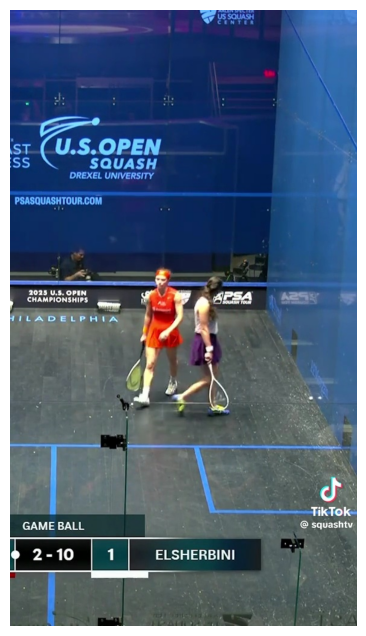

In [12]:
image = cv2.imread("../data/samples/frame_000216.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

show_image(image_rgb)

In [14]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# GaussianBlur to reduce noise and help edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, 50, 150)

In [15]:

# Apply a dilation and erosion to close gaps in contours
kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1) # expand light parts in the image
eroded = cv2.erode(dilated, kernel, iterations=1) # minimize the light parts in the image

## Countours

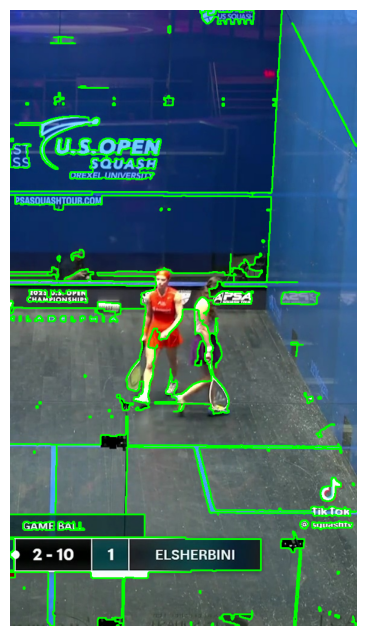

In [24]:
# Find contours in the eroded image
contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
vis = image_rgb.copy()
vis = cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)  # green, thickness 2
show_image(vis)

## HoughLines

In [16]:
# Create a blank image to draw the lines
line_image = np.zeros_like(image_rgb)

In [17]:

# Use Hough Line Transform to detect lines
lines = cv2.HoughLinesP(eroded, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)

In [18]:

# Draw the detected lines on the blank image
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

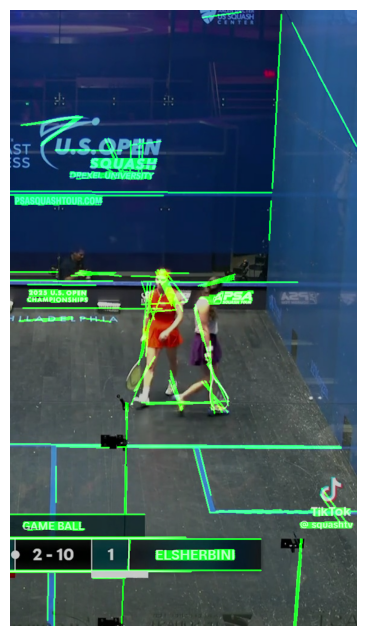

In [19]:

# Combine the original image with the lines
image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
result = cv2.addWeighted(image_rgb, 0.8, line_image, 1, 0)

# Display the result
show_image(result)